In [ ]:
"""
Metadata:

Developer: Swapnendu Banik
Version: 1.0.0
Date: 2023-11-21
Description: This project demonstrates object detection using the YOLO (You Only Look Once) framework. 
It includes scripts for training, inference, and evaluation, along with a dataset for dog breed detection.

Dependencies:
- ultralytics

Usage:
- Refer to the README.md file for detailed instructions on project setup, data preparation, training, and inference.

License: MIT
"""

### Importing Dependencies

In [1]:
import os

In [4]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\nirma\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Path inside runs folder to the best.pt model
Runs folder is automatically created when a YOLO model is done training

In [18]:
model_path="results/runs/detect/train2/weights"

In [19]:
model = YOLO(f"{model_path}/best.pt")

In [27]:
predict_images_names=os.listdir( "dog_breed_predict_images") ## Listing all the files inside the predict folder
predict_images_names

['bichon_1.jpeg',
 'bichon_2.jpeg',
 'chihuahua_1.jpeg',
 'chihuahua_2.webp',
 'maltese_1.jpeg',
 'maltese_2.png',
 'pomeranian_1.jpeg',
 'pomeranian_2.jpeg',
 'poodle_1.jpeg',
 'poodle_2.jpeg']

In [25]:
img_pred_list=[f"dog_breed_predict_images/{x}" for x in predict_images_names] ## Getting the path of all the images to be predicted in a list.
img_pred_list 

['dog_breed_predict_images/bichon_1.jpeg',
 'dog_breed_predict_images/bichon_2.jpeg',
 'dog_breed_predict_images/chihuahua_1.jpeg',
 'dog_breed_predict_images/chihuahua_2.webp',
 'dog_breed_predict_images/maltese_1.jpeg',
 'dog_breed_predict_images/maltese_2.png',
 'dog_breed_predict_images/pomeranian_1.jpeg',
 'dog_breed_predict_images/pomeranian_2.jpeg',
 'dog_breed_predict_images/poodle_1.jpeg',
 'dog_breed_predict_images/poodle_2.jpeg']

### Prediction and Visualization Block
The original name of the image is given as the tilte of the output images, the predicted label is around the boundig box


0: 640x640 1 Bichon, 48.5ms
1: 640x640 1 Maltese, 48.5ms
2: 640x640 2 Chihuahuas, 48.5ms
3: 640x640 3 Chihuahuas, 48.5ms
4: 640x640 1 Maltese, 48.5ms
5: 640x640 3 Malteses, 48.5ms
6: 640x640 1 Pomeranian, 48.5ms
7: 640x640 3 Pomeranians, 48.5ms
8: 640x640 1 Poodle, 48.5ms
9: 640x640 1 Poodle, 48.5ms
Speed: 1.8ms preprocess, 48.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


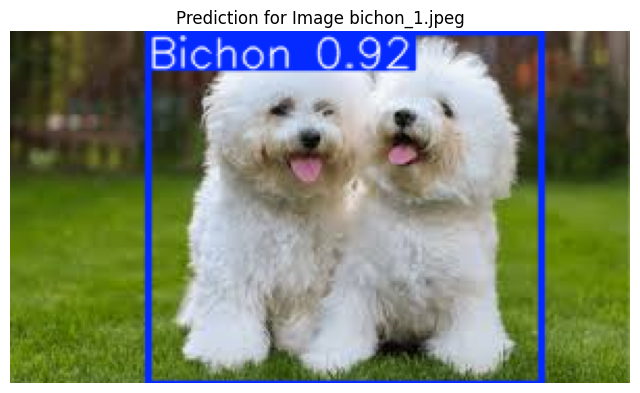

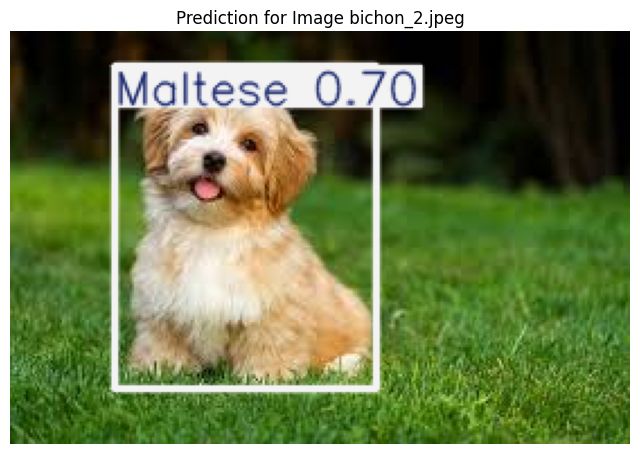

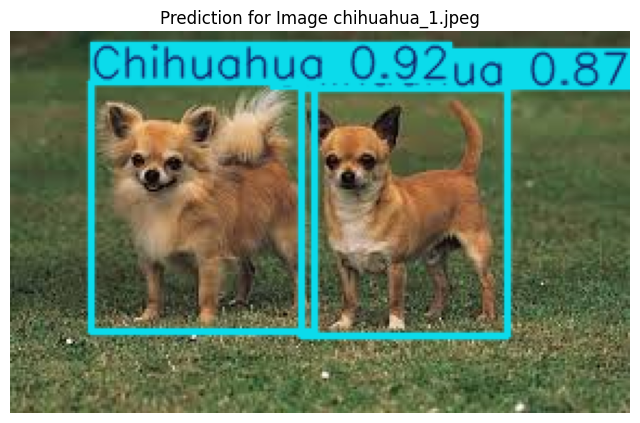

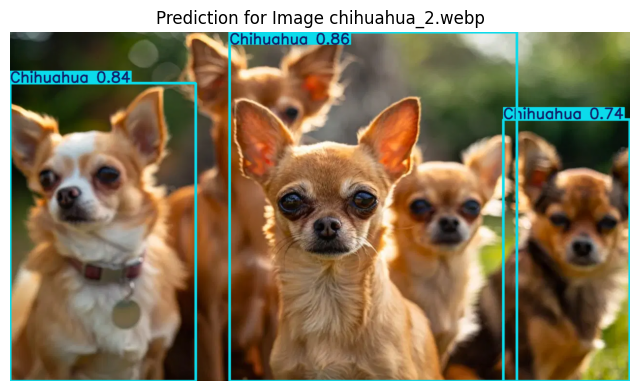

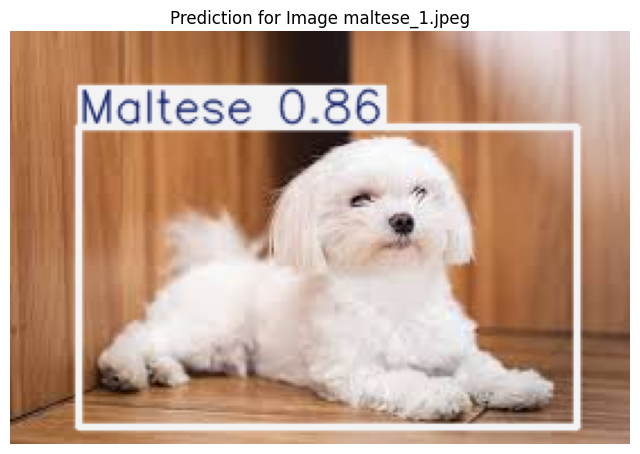

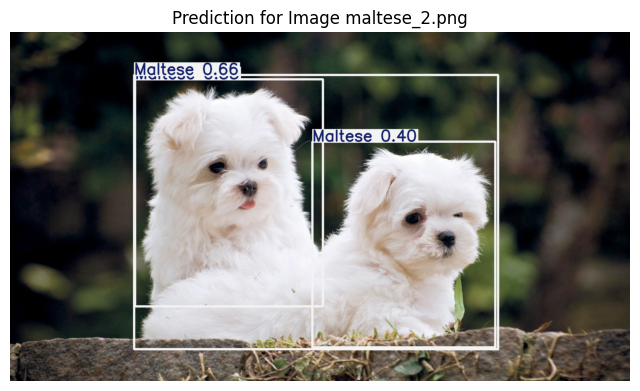

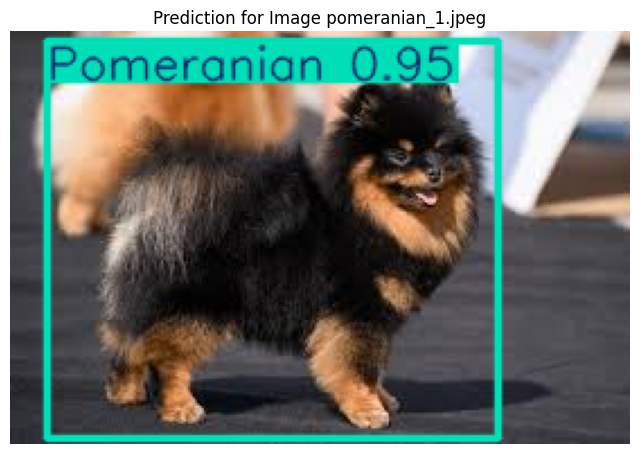

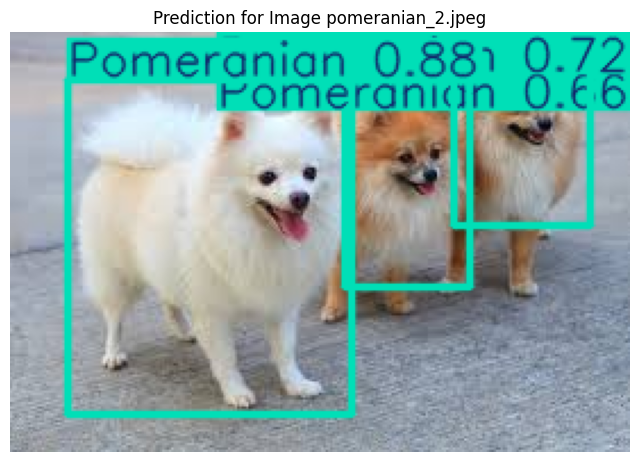

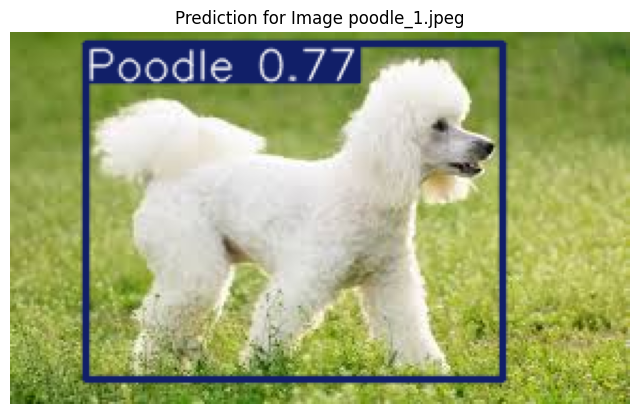

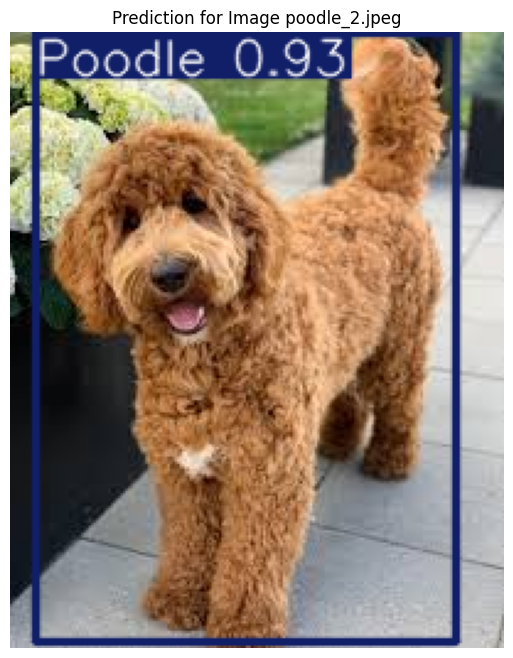

In [26]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Run batched inference on a list of images
results = model(img_pred_list)  # return a list of Results objects

# Process results list
for i, result in enumerate(results):
    boxes = result.boxes  # Bounding box outputs
    probs = result.probs  # Classification outputs
    
    # Get the image with predictions drawn (returns a PIL Image)
    pred_image = result.plot()  # Use .plot() to get the image with bounding boxes

    # Convert BGR to RGB if needed
    if pred_image.shape[-1] == 3:  # Ensure it's a color image
        pred_image = pred_image[..., ::-1]  # Convert BGR to RGB
    
    # Display using Matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(pred_image)
    plt.axis('off')  # Turn off axes for better visualization
    plt.title(f"Prediction for Image {predict_images_names[i]}")
    plt.show()